## Gather metrics from model training and put them in a nice table.

Run the commands

``` python3 train_models.py hyperparameters.json <ModelClass> <dataset> ``` for model trainig

``` python3 train_models.py hyperparameters.json <ModelClass> <dataset> --retrain ``` to run cross validation with the best hyperparameters.

We obtain the standard metrics for classification, as well as the calibration-independen metrics in this notebook.

In [2]:
## All the implemented models.
models = ["NaiveBayesBOWmodel", "NGramLogisticRegression", "FeedForwardModel", "BERTmodel", "RoBERTamodel", "BERTPretrainedmodel", "RoBERTaPretrainedmodel"] #OpenAImodel

## OpenAImodel is not used here, as there is no hyperparamter search and no averaging over runs.
## See model training log-file for metrics.

In [3]:
%load_ext autoreload
%autoreload 2

First, we obtain standard metrics from the log-files.

In [4]:
import json
hyperparameters = json.load(open("hyperparameters.json"))

In [5]:
from src.dataset import load_gtc
genocide_ds = load_gtc("Dataset_GTC-V2.csv", format="transformers")

In [6]:
from train_models import get_dataset

In [7]:
get_dataset("All")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 17083
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4173
    })
})

In [8]:
type(genocide_ds["train"]["text"])

list

In [9]:
def param_string(params):
    mystr = ""
    for k, v in params.items():
        if mystr != "":
            mystr += "_"
        mystr +=str(k) + "-" + str(v)
    return mystr.replace("[","(").replace("]",")")

In [10]:
def get_init_params(hyperparameters_model, bestparameters, at_init=True):
    ret_dict = {}
    for pdict in hyperparamters_model:
        if pdict["at_init"] == at_init:
            ret_dict[pdict["name"]] = best_parameters[pdict["name"]]
    return ret_dict

## Print the metrics with standard errors for the main table

In [11]:
dataset = "xyz"

In [12]:
import torch
import pandas as pd
import numpy as np
import os
from train_models import get_dataset

LOG_MODEL_PREDS = "logs_{}/models/{}"

def extract_metrics(model, parameters, metric_list=["accuracy_score", "precision_score", "recall_score", "f1_score", "roc_auc_score"], dataset="GTC"):
    res = json.load(open(f"logs_{dataset}/hyperparams{model}.json"))
    str = ""
    for key, vals in res:
        if "device" in key:
            del key["device"]
        if key==parameters:
            for i in metric_list:
                if i in vals:
                    str += f"{vals[i]:.2f}\t"
            break
    return str

def get_best_params(model, dataset):
    res = json.load(open(f"logs_{dataset}/best_params_{model}.json"))
    return res

def print_best_metrics(model, metric_list=["accuracy_score","f1_score", "roc_auc_score"], dataset="GTC"):
    print(extract_metrics(model, get_best_params(model, dataset), metric_list, dataset))
    
def load_predictions(model, run, dataset):
    parameters = get_best_params(model, dataset)
    if os.path.exists(LOG_MODEL_PREDS.format(dataset, model + "_" + param_string(parameters))+ f"_{dataset}_r{run}-preds.pt"):
        preds = torch.load(LOG_MODEL_PREDS.format(dataset, model + "_" + param_string(parameters))+ f"_{dataset}_r{run}-preds.pt")
    else:
        #print("caution, loading GTC predictions")
        preds = torch.load(LOG_MODEL_PREDS.format(dataset, model + "_" + param_string(parameters))+ f"_r{run}-preds.pt")
    return preds

from src.compute_metrics import compute_metrics_list

def agg_metrics(model, num_runs = 5, metric_list=["f1_score", "roc_auc_score"], dataset="GTC"):
    all_list = []
    for run in range(num_runs):
        seed = run*49
        if dataset == "GTC" and ("Pretrained" in model or "RoBERTa" in model):
            if run == 0:
                seed=1
        myds = get_dataset(dataset, seed=seed)
        pred = load_predictions(model, run, dataset)
        all_list.append(compute_metrics_list(metric_list, pred, myds["test"]["label"]))
    df = pd.DataFrame(all_list).values
    #print(df)
    return df.mean(axis=0), df.std(axis=0)/np.sqrt(num_runs-1)

def print_all_metric_table(models = models, dataset = "GTC", metric_list =["f1_score", "roc_auc_score"]): ## Print the metrics for the table in the main paper.
    for m in models:
        res_mean, res_std = agg_metrics(m, dataset=dataset, metric_list=metric_list)
        mystr = ""
        for x in range(len(res_mean)):
            mystr += " & "
            mystr += r"\wstd{" + f"{res_mean[x]:.2f}" +r"}{" f"{res_std[x]:.2f}" + "} "
        print(m + mystr + r"\\")

In [37]:
print_all_metric_table(metric_list=["accuracy_score", "precision_score", "recall_score"])

NaiveBayesBOWmodel & \wstd{0.84}{0.03}  & \wstd{0.44}{0.08}  & \wstd{0.69}{0.12} \\
NGramLogisticRegression & \wstd{0.88}{0.02}  & \wstd{0.60}{0.12}  & \wstd{0.44}{0.09} \\
FeedForwardModel & \wstd{0.88}{0.02}  & \wstd{0.60}{0.12}  & \wstd{0.46}{0.09} \\
BERTmodel & \wstd{0.88}{0.03}  & \wstd{0.58}{0.12}  & \wstd{0.46}{0.10} \\
RoBERTamodel & \wstd{0.91}{0.00}  & \wstd{0.70}{0.02}  & \wstd{0.59}{0.05} \\
BERTPretrainedmodel & \wstd{0.92}{0.00}  & \wstd{0.74}{0.03}  & \wstd{0.70}{0.04} \\
RoBERTaPretrainedmodel & \wstd{0.93}{0.00}  & \wstd{0.75}{0.03}  & \wstd{0.74}{0.04} \\


In [16]:
print_all_metric_table(models=["FeedForwardModel", "BERTPretrainedmodel", "RoBERTaPretrainedmodel"], dataset="GTC",metric_list=["f1_score", "roc_auc_score"])

FeedForwardModel & \wstd{0.52}{0.10}  & \wstd{0.84}{0.09} \\
BERTPretrainedmodel & \wstd{0.71}{0.01}  & \wstd{0.96}{0.00} \\
RoBERTaPretrainedmodel & \wstd{0.74}{0.01}  & \wstd{0.97}{0.00} \\


In [38]:
print_all_metric_table(models=["NaiveBayesBOWmodel", "NGramLogisticRegression", "FeedForwardModel", "BERTPretrainedmodel", "RoBERTaPretrainedmodel"], dataset="PTSD",metric_list=["accuracy_score", "precision_score", "recall_score"])

NaiveBayesBOWmodel & \wstd{0.69}{0.01}  & \wstd{0.63}{0.02}  & \wstd{0.52}{0.06} \\
NGramLogisticRegression & \wstd{0.68}{0.01}  & \wstd{0.62}{0.03}  & \wstd{0.54}{0.03} \\
FeedForwardModel & \wstd{0.70}{0.01}  & \wstd{0.71}{0.04}  & \wstd{0.42}{0.05} \\
BERTPretrainedmodel & \wstd{0.72}{0.01}  & \wstd{0.64}{0.01}  & \wstd{0.69}{0.06} \\
RoBERTaPretrainedmodel & \wstd{0.75}{0.01}  & \wstd{0.66}{0.02}  & \wstd{0.78}{0.04} \\


In [39]:
print_all_metric_table(models=["NaiveBayesBOWmodel", "NGramLogisticRegression", "FeedForwardModel", "BERTPretrainedmodel", "RoBERTaPretrainedmodel"], dataset="Counseling",metric_list=["accuracy_score", "precision_score", "recall_score"])

NaiveBayesBOWmodel & \wstd{0.26}{0.01}  & \wstd{0.09}{0.01}  & \wstd{0.99}{0.01} \\
NGramLogisticRegression & \wstd{0.92}{0.01}  & \wstd{0.55}{0.17}  & \wstd{0.09}{0.03} \\


Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


FeedForwardModel & \wstd{0.92}{0.01}  & \wstd{0.10}{0.10}  & \wstd{0.02}{0.02} \\
BERTPretrainedmodel & \wstd{0.93}{0.01}  & \wstd{0.54}{0.04}  & \wstd{0.27}{0.05} \\
RoBERTaPretrainedmodel & \wstd{0.91}{0.01}  & \wstd{0.36}{0.19}  & \wstd{0.20}{0.12} \\


Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


In [42]:
print_best_metrics("OpenAImodel", dataset="GTC", metric_list=["accuracy_score", "precision_score", "recall_score"]) ## For OpenAI model only use 1 run.

0.91	0.68	0.61	


## Recalibrate models for maxacc.

Still Needs to be adapted. Do we need this for final paper?

In [6]:
import src.classification_models as cls_model
import torch
LOG_MODEL = "logs/models/{}.pt"
USE_MODEL = "RoBERTamodel"
parameters = get_best_params(USE_MODEL)


myobjcls = getattr(cls_model, USE_MODEL)
myobj = myobjcls()
LOG_MODEL = "logs/models/{}.pt"
print(parameters)
myobj.load(LOG_MODEL.format(USE_MODEL + "_" + param_string(parameters)))
## Test phase
probas = myobj.predict_proba(genocide_ds["test"]["text"])
torch.save(probas, f"logs/models/{USE_MODEL}-preds.pt")

{'n_layers': 13, 'n_heads': 8, 'd_hidden': 384, 'lr': 1.0416009650560746e-05}


Having stored the predicitons, we can now evaluat the metrics max accuracy (with best threshold), precision@recall=0.75
For the maximum accuracy, we can also return the threshold.

In [7]:
import torch
scores_ffn = torch.load("logs/models/FeedForwardModel-preds.pt")
scores_nb = torch.load("logs/models/NaiveBayesBOWmodel-preds.pt")
scores_ngram = torch.load("logs/models/NGramLogisticRegression-preds.pt")
scores_bert = torch.load("logs/models/BERTmodel-preds.pt")
scores_roberta = torch.load("logs/models/RoBERTamodel-preds.pt")
scores_gpt = torch.load("logs/models/OpenAImodel_target_model-gpt-4-turbo-preds.pt")
scores_gpt3 = torch.load("logs/models/OpenAImodel_target_model-gpt-3.5-turbo-preds.pt")

In [8]:
from sklearn.metrics import roc_curve
import numpy as np
    
def compute_maxacc(fpr_var, tpr_var, thres, labels):
    acc_vals = labels.mean()*tpr_var + (1-labels.mean())*(1-fpr_var)
    acc_idx = np.argmax(acc_vals)
    return acc_vals[acc_idx], thres[acc_idx]

def compute_precision(fpr_var, tpr_var, thres, preds, labels, at_recall=0.75):
    tpr_match = (tpr_var >= at_recall)
    use_thres = np.max(thres[tpr_match])
    all_pred_pos = labels[preds > use_thres]
    return all_pred_pos.mean()
    
for name, scores in zip(["FFN", "NB", "NGram", "BERT", "RoBERTa", "GPT3.5", "GPT4"], [scores_ffn, scores_nb, scores_ngram, scores_bert, scores_roberta, scores_gpt3, scores_gpt]):
    fpr_var, tpr_var, thres = roc_curve(np.array(genocide_ds["test"]["label"]), scores[:,1])
    maxacc, thres_opt = compute_maxacc(fpr_var, tpr_var, thres, np.array(genocide_ds["test"]["label"]))
    print(name, f"Max-Accuracy: {maxacc:.3f}, Threshold={thres_opt:.3f}")
    print(name, f"Precision@0.75: {compute_precision(fpr_var, tpr_var, thres, scores[:,1], np.array(genocide_ds['test']['label']), at_recall=0.75):.3f}")

FFN Max-Accuracy: 0.918, Threshold=0.517
FFN Precision@0.75: 0.616
NB Max-Accuracy: 0.912, Threshold=0.997
NB Precision@0.75: 0.594
NGram Max-Accuracy: 0.912, Threshold=0.398
NGram Precision@0.75: 0.588
BERT Max-Accuracy: 0.913, Threshold=0.810
BERT Precision@0.75: 0.580
RoBERTa Max-Accuracy: 0.916, Threshold=0.489
RoBERTa Precision@0.75: 0.644
GPT3.5 Max-Accuracy: 0.905, Threshold=0.991
GPT3.5 Precision@0.75: 0.562
GPT4 Max-Accuracy: 0.909, Threshold=0.997
GPT4 Precision@0.75: 0.582


## Print agreement metrics

In [17]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd

In [30]:
names_list = ["FFN", "NB", "NGram", "BERT", "GPT3.5", "GPT4"]
models_list = [scores_ffn, scores_nb, scores_ngram, scores_bert, scores_gpt3, scores_gpt]
res_mat = [] # = np.zeros((len(models_list), len(models_list)))
for idx, scores in enumerate(models_list):
    m1_dict = {}
    for idx2, scores2 in enumerate(models_list):
        m1_dict[names_list[idx2]] = cohen_kappa_score((scores[:,1]> 0.5), (scores2[:,1] > 0.5))
    res_mat.append(m1_dict)
dset = pd.DataFrame(res_mat, index=names_list)

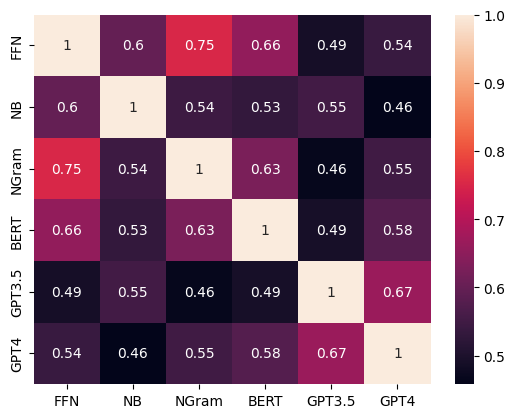

In [31]:
import seaborn as sns
plot = sns.heatmap(dset, annot=True)